# Training Deep Neural Network on a GPU with Pytorch

## Preparing Data

In [3]:
import torch
import numpy as np
import torchvision
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data.dataloader import DataLoader

In [4]:
dataset = MNIST(root="data/",
                download=True,
                transform=ToTensor())

In [5]:
dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: data/
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
img, label = dataset[0]
img.shape, label

(torch.Size([1, 28, 28]), 5)

<function matplotlib.pyplot.show(close=None, block=None)>

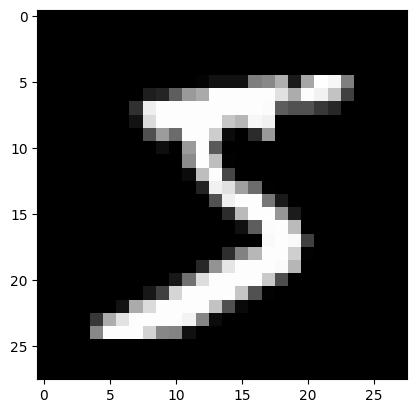

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(img[0], cmap="gray")
plt.show

In [8]:
img[0, 10:15, 10:15]

tensor([[0.0039, 0.6039, 0.9922, 0.3529, 0.0000],
        [0.0000, 0.5451, 0.9922, 0.7451, 0.0078],
        [0.0000, 0.0431, 0.7451, 0.9922, 0.2745],
        [0.0000, 0.0000, 0.1373, 0.9451, 0.8824],
        [0.0000, 0.0000, 0.0000, 0.3176, 0.9412]])

In [9]:
def split_indices(n, val_pct):
    n_val = int(n*val_pct)
    indx = np.random.permutation(n)
    return indx[n_val:], indx[:n_val]

In [10]:
train_indices, val_indices = split_indices(len(dataset), val_pct=0.2)

print(len(train_indices), len(val_indices))
print("Sample val indices: ", val_indices[:20])

48000 12000
Sample val indices:  [ 4079 32899 59060 14084  2279  5673 37477 26501 44728 54326 11219 25141
 19377 38123 58321 24559 45178 21428 34951  2639]


In [11]:
batch_size = 100

#Training sampler and data loader
train_sampler = SubsetRandomSampler(train_indices)
train_dl = DataLoader(dataset,
                      batch_size,
                      sampler=train_sampler)

#Validation sampler and data loader
val_sampler = SubsetRandomSampler(val_indices)
val_dl = DataLoader(dataset,
                      batch_size,
                      sampler=train_sampler)

## Model

In [13]:
import torch.nn.functional as F
import torch.nn as nn

In [14]:
class MnistModel(nn.Module):
    def __init__(self, in_size, hidden_size, out_size):
        super().__init__()
        #hidden layer
        self.linear1 = nn.Linear(in_size, hidden_size)
        #output layer
        self.linear2 = nn.Linear(hidden_size, out_size)

    def forward(self, xb):
        #Flatten the image tensors
        xb = xb.view(xb.size(0), -1)
        #Get Intermediate Output using Hidden Layer
        out = self.linear1(xb)
        #Apply the activation function
        out = F.relu(out)
        #Get the predcition using Ouput Layer
        out = self.linear2(out)
        return out

In [15]:
input_size = 784
num_classes = 10

model = MnistModel(input_size, hidden_size=32, out_size=num_classes)

In [16]:
for t in model.parameters():
    print(t.shape)

torch.Size([32, 784])
torch.Size([32])
torch.Size([10, 32])
torch.Size([10])


In [17]:
for images, labels in train_dl:
    print(images.shape)
    outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    print("Loss: ", loss.item())
    break

print("output.shape: ", outputs.shape)
print("Sample ouputs: \n", outputs[:2].data)

torch.Size([100, 1, 28, 28])
Loss:  2.2944726943969727
output.shape:  torch.Size([100, 10])
Sample ouputs: 
 tensor([[-8.7277e-02,  6.6575e-02,  1.5109e-01,  5.2992e-02,  9.2767e-02,
          5.3960e-03, -5.3436e-02, -1.8345e-01,  8.6828e-02,  4.8138e-05],
        [-7.3299e-02,  8.2417e-02,  6.1476e-02,  5.3999e-02,  1.2707e-01,
         -6.4262e-02, -1.0847e-01, -1.9471e-01,  1.2159e-01,  9.2662e-02]])


## Using GPU

In [19]:
torch.cuda.is_available()

True

In [20]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

In [21]:
device = get_default_device()
device

device(type='cuda')

In [22]:
def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

In [23]:
for images, labels in train_dl:
    print(images.shape)
    images = to_device(images, device)
    print(images.device)
    break

torch.Size([100, 1, 28, 28])
cuda:0


In [24]:
class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

In [25]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)

In [26]:
for xb, yb in val_dl:
    print("xb.device: ", xb.device)
    print("yb: ", yb)
    break

xb.device:  cuda:0
yb:  tensor([1, 8, 3, 3, 5, 3, 1, 3, 2, 9, 4, 9, 8, 8, 0, 9, 6, 2, 8, 8, 1, 6, 9, 8,
        6, 9, 5, 5, 6, 8, 8, 6, 1, 5, 1, 4, 8, 0, 2, 9, 6, 4, 7, 1, 7, 8, 2, 4,
        1, 8, 5, 4, 2, 2, 0, 9, 1, 6, 8, 4, 7, 0, 8, 1, 9, 9, 6, 6, 0, 9, 2, 0,
        7, 3, 4, 1, 7, 8, 9, 1, 6, 8, 1, 3, 7, 8, 8, 5, 0, 7, 4, 6, 7, 0, 2, 0,
        5, 9, 8, 5], device='cuda:0')


## Training the Model

In [28]:
def loss_batch(model, loss_func, xb, yb, opt=None, metric=None):
     #Generate predictions
    preds = model(xb)
    #Calculate loss
    loss = loss_func(preds, yb)

    if opt is not None:
        #Compute gradients
        loss.backward()
        #Update parameters
        opt.step()
        #Reset Gradeints
        opt.zero_grad()

    metric_result = None
    if metric is not None:
        #Compute the metric
        metric_result = metric(preds, yb)

    return loss.item(), len(xb), metric_result

In [29]:
def evaluate(mdoel, loss_fn, valid_dl, metric=None):
    with torch.no_grad():
        #Pass each batch through the model
        results = [loss_batch(model, loss_fn, xb, yb, metric=metric)
                   for xb, yb in valid_dl]
        #Separate losses, counts and metrics
        losses, nums, metrics = zip(*results)
        #Total size of the dataset
        total = np.sum(nums)
        #Avg loss across batches
        avg_loss = np.sum(np.multiply(losses, nums)) / total
        avg_metric = None
        if metric is not None:
            #Avg of metric across batches
            avg_metric = np.sum(np.multiply(metrics, nums)) / total
        return avg_loss, total, avg_metric

In [30]:
def fit(epochs, lr, model, loss_fn, train_dl, valid_dl, metric=None, opt_fn=None):
    losses, metrics = [], []

    #Instantiate the optimizer
    if opt_fn is None: opt_fn = torch.optim.SGD
    opt = opt_fn(model.parameters(), lr=lr)

    for epoch in range(epochs):
        #Training
        for xb, yb in train_dl:
            loss_batch(model, loss_fn, xb, yb, opt)

        #Evaluation
        result = evaluate(model, loss_fn, valid_dl, metric)
        val_loss, total, val_metric = result

        #Record the loss & metric
        losses.append(val_loss)
        # metric.append(val_metric)

        #Print progress
        if metric is None:
            print("Epoch [{}/{}], Loss: {:.4f}".format(epoch+1, epochs, val_loss))
        else:
            print("Epoch [{}/{}], Loss: {:.4f}, {}: {:.4f}".format(epoch+1, epochs, val_loss, metric.__name__, val_metric))

    return losses, metrics

In [31]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.sum(preds == labels).item() / len(preds)

In [32]:
model = MnistModel(input_size, hidden_size=32, out_size=num_classes)
to_device(model, device)

MnistModel(
  (linear1): Linear(in_features=784, out_features=32, bias=True)
  (linear2): Linear(in_features=32, out_features=10, bias=True)
)

In [33]:
val_loss, total, val_acc = evaluate(model, F.cross_entropy, val_dl, metric=accuracy)
print("Loss {:.4f}, Accuracy: {:.4f}".format(val_loss, val_acc))

Loss 2.3078, Accuracy: 0.1173


In [34]:
losses1, metrics1 = fit(5, 0.5, model, F.cross_entropy, train_dl, val_dl, accuracy)

Epoch [1/5], Loss: 0.1880, accuracy: 0.9453
Epoch [2/5], Loss: 0.1573, accuracy: 0.9529
Epoch [3/5], Loss: 0.1221, accuracy: 0.9628
Epoch [4/5], Loss: 0.1027, accuracy: 0.9696
Epoch [5/5], Loss: 0.0889, accuracy: 0.9735


In [35]:
losses2, metrics2 = fit(5, 0.1, model, F.cross_entropy, train_dl, val_dl, accuracy)

Epoch [1/5], Loss: 0.0703, accuracy: 0.9798
Epoch [2/5], Loss: 0.0668, accuracy: 0.9810
Epoch [3/5], Loss: 0.0672, accuracy: 0.9803
Epoch [4/5], Loss: 0.0623, accuracy: 0.9823
Epoch [5/5], Loss: 0.0606, accuracy: 0.9830


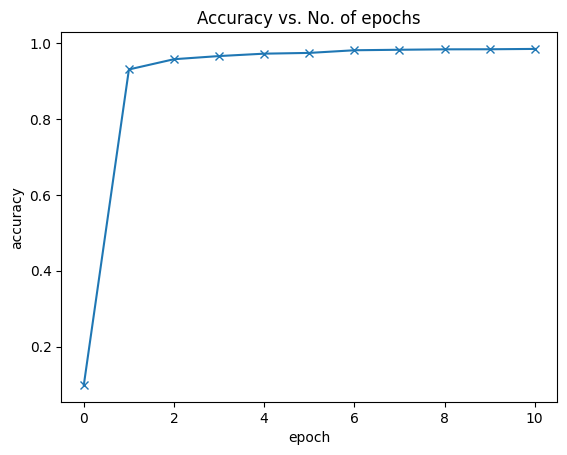

In [36]:
accuracies = [0.0992, 0.9304, 0.9574, 0.9657, 0.9720, 0.9740, 
              0.9810, 0.9823, 0.9834, 0.9836, 0.9845]
plt.plot(accuracies, '-x')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy vs. No. of epochs');